In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

from psr import estimate_delay_ami, estimate_dimension_fnn, AMIConfig, FNNConfig, reconstruct_matrix
from lyapunov import lyapunov_wolf_ode, wolf_mle, AttractorODEConfig, WolfODEConfig, WolfConfig

Time series length: 18000 samples, dt = 0.01 s


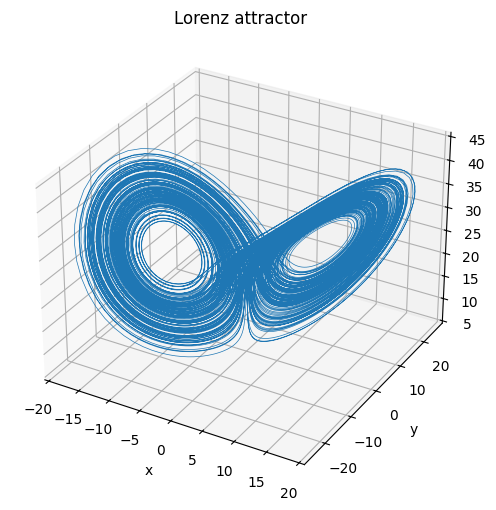

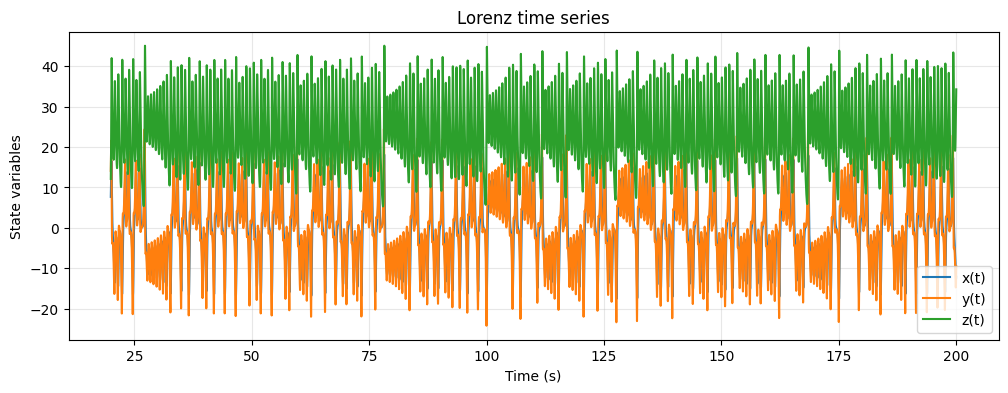

In [2]:
# Lorenz system and simulation
def lorenz_ode(state, t, sigma, rho, beta):
    x, y, z = state
    return np.array([sigma*(y - x), x*(rho - z) - y, x*y - beta*z])

def lorenz_jacobian(state, t, sigma, rho, beta):
    x, y, z = state
    return np.array([[-sigma, sigma, 0],
                     [rho - z, -1, -x],
                     [y, x, -beta]])

# parameters
sigma, rho, beta = 10, 28, 8/3
dt = 0.01
total_time = 200.0
t = np.arange(0, total_time, dt)

# initial condition
x0 = np.array([1.0, 1.0, 1.0])


sol = solve_ivp(lambda t, y: lorenz_ode(y, t, sigma, rho, beta),
                [0, total_time], x0, t_eval=t, method='RK45')
Y = sol.y  

# Discard transient 
transient_steps = 2000
x_series = Y[0, transient_steps:]
y_series = Y[1, transient_steps:]
z_series = Y[2, transient_steps:]
t_clean = t[transient_steps:]

print(f"Time series length: {len(x_series)} samples, dt = {dt} s")

# Plot Lorenz attractor
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(Y[0, transient_steps:], Y[1, transient_steps:], Y[2, transient_steps:], lw=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Lorenz attractor')
plt.show()

# Time series
plt.figure(figsize=(12,4))
plt.plot(t_clean, x_series, label='x(t)')
plt.plot(t_clean, y_series, label='y(t)')
plt.plot(t_clean, z_series, label='z(t)')
plt.xlabel('Time (s)')
plt.ylabel('State variables')
plt.legend()
plt.title('Lorenz time series')
plt.grid(alpha=0.3)
plt.show()

# Part A — Phase Space Reconstruction (PSR)

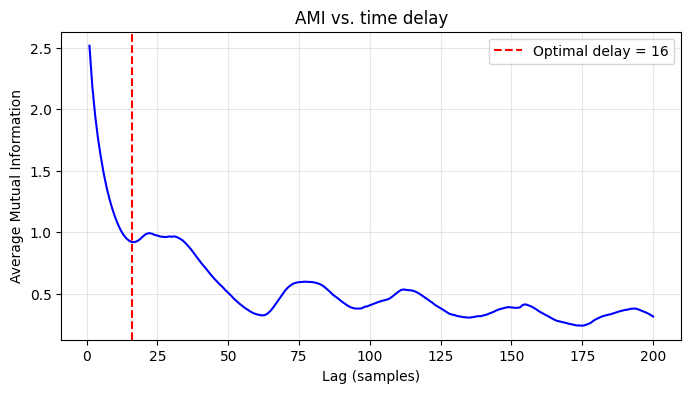

Optimal time delay = 16


In [3]:
# Time Delay via AMI
ami_cfg = AMIConfig(max_lag=200, n_bins=32, criterion='first_local_min')
tau_opt, lags, ami_vals = estimate_delay_ami(x_series, cfg=ami_cfg, standardize=True)

plt.figure(figsize=(8,4))
plt.plot(lags, ami_vals, 'b-', lw=1.5)
plt.axvline(tau_opt, color='r', linestyle='--', label=f'Optimal delay = {tau_opt}')
plt.xlabel('Lag (samples)')
plt.ylabel('Average Mutual Information')
plt.title('AMI vs. time delay')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal time delay = {tau_opt}")

Mean orbital period: 97.9 samples (=0.979 s)


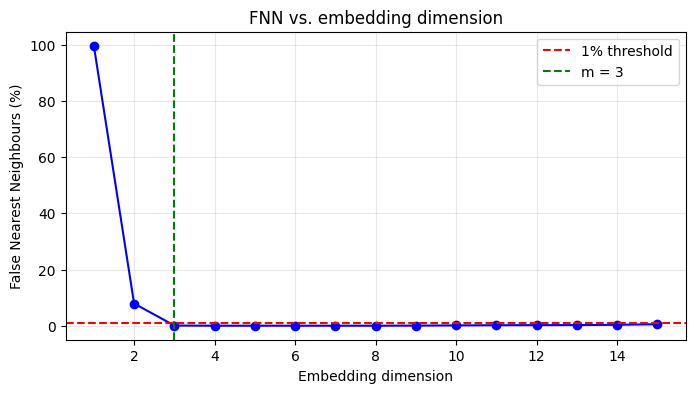

Optimal embedding dimension m = 3


In [4]:
# Embedding Dimension via FNN
from scipy.signal import find_peaks

peaks, _ = find_peaks(x_series, distance=50)  # approximate min distance
if len(peaks) > 1:
    mean_period_samples = np.mean(np.diff(peaks))
else:
    mean_period_samples = 100  # fallback
print(f"Mean orbital period: {mean_period_samples:.1f} samples (={mean_period_samples*dt:.3f} s)")
theiler_window = int(mean_period_samples)  # use as Theiler window

fnn_cfg = FNNConfig(max_dim=15, R_tol=10.0, A_tol=2.0,
                    threshold_percent=1.0, theiler=theiler_window)
m_opt, dims, fnn_pct = estimate_dimension_fnn(x_series, tau=tau_opt, cfg=fnn_cfg, standardize=True)

plt.figure(figsize=(8,4))
plt.plot(dims, fnn_pct, 'o-', color='b', lw=1.5)
plt.axhline(1.0, color='r', linestyle='--', label='1% threshold')
plt.axvline(m_opt, color='g', linestyle='--', label=f'm = {m_opt}')
plt.xlabel('Embedding dimension')
plt.ylabel('False Nearest Neighbours (%)')
plt.title('FNN vs. embedding dimension')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal embedding dimension m = {m_opt}")

# Part B — Lyapunov Exponent

In [5]:
# From the ODE — Wolf's Gram–Schmidt Reorthogonalisation (GSR) Method
ode_cfg = AttractorODEConfig(
    ode=lorenz_ode,
    jacobian=lorenz_jacobian,
    x0=np.array([1.0, 1.0, 1.0]),
    params=(sigma, rho, beta),
    dt=dt,
    transient_steps=2000,
    n_steps=30000,
    solver='RK45',
    solver_options={'rtol': 1e-9, 'atol': 1e-12}
)
wolf_ode_cfg = WolfODEConfig(ortho_steps=20, log_base='e')  # nats per second

spectrum = lyapunov_wolf_ode(ode_cfg, wolf_ode_cfg)
spectrum_sorted = np.sort(spectrum)[::-1]
lambda1_ode = spectrum_sorted[0]
print("Lyapunov spectrum (nats/time):", spectrum)
print(f"Largest Lyapunov exponent from ODE: lamda1 = {lambda1_ode:.4f} nats/s")

Lyapunov spectrum (nats/time): [ 8.95163071e-01 -4.28712766e-03 -1.45575426e+01]
Largest Lyapunov exponent from ODE: lamda1 = 0.8952 nats/s


In [6]:
# From a Time Series — Wolf's Phase-Space Tracking Method
wolf_ts_cfg = WolfConfig(
    theiler_window=theiler_window,
    min_dist_scale=1e-3,
    max_dist_scale=1e-1,
    evolve_cap=50,
    max_replacements=300,
    angle_weight=0.3
)

mle_bits, debug = wolf_mle(x_series, dt=dt, tau=tau_opt, m=m_opt,
                           cfg=wolf_ts_cfg, return_debug=True)
print(f"Largest Lyapunov exponent from time series: lamda1 = {mle_bits:.4f} bits/s")
print(f"Number of replacements (segments): {debug['replacements']}")

# Convert to nats for comparison
mle_nats = mle_bits * np.log(2)
print(f"Converted to nats: {mle_nats:.4f} nats/s")
print(f"ODE estimate: {lambda1_ode:.4f} nats/s")
print(f"Relative difference: {abs(mle_nats - lambda1_ode)/lambda1_ode*100:.1f}%")

Largest Lyapunov exponent from time series: lamda1 = 2.3654 bits/s
Number of replacements (segments): 300
Converted to nats: 1.6396 nats/s
ODE estimate: 0.8952 nats/s
Relative difference: 83.2%


# Part D — Correlation Dimension

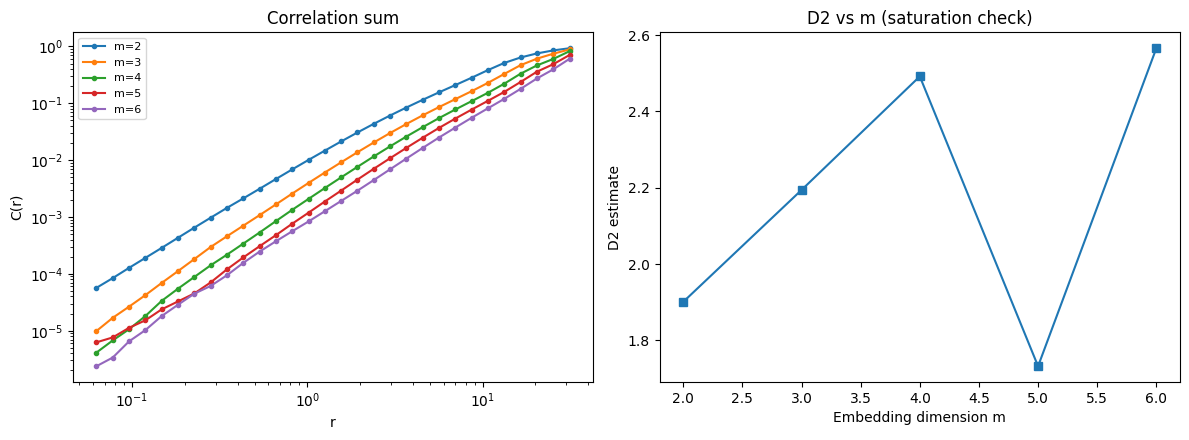

D2 estimates by m: m=2: 1.901, m=3: 2.194, m=4: 2.492, m=5: 1.732, m=6: 2.566
Saturated D2 (approx.): 2.149 (Lorenz attractor ~ 2.0–2.1)


In [7]:
def correlation_sum(X, radii, theiler_window):
    # Grassberger-Procaccia correlation sum with Theiler exclusion
    M = len(X)
    max_points = 4000
    if M > max_points:
        idx = np.linspace(0, M - 1, max_points, dtype=int)
        X = X[idx]
        M = len(X)

    counts = np.zeros(len(radii), dtype=float)

    for i in range(M - 1):
        j_min = i + 1
        diffs = X[j_min:] - X[i]
        dists = np.linalg.norm(diffs, axis=1)
        js = np.arange(j_min, M)
        valid = np.abs(js - i) > theiler_window
        dists = dists[valid]
        if dists.size == 0:
            continue
        for k, r in enumerate(radii):
            counts[k] += np.sum(dists < r)

    return 2.0 * counts / (M * (M - 1))


def estimate_d2_from_curve(radii, C, r_min_frac=0.01, r_max_frac=0.15):
    # Fit slope of log C vs log r
    mask = (C > 0) & np.isfinite(C)
    r = radii[mask]
    c = C[mask]
    if len(r) < 5:
        return np.nan, None, None
    log_r = np.log10(r)
    log_c = np.log10(c)
    lo = np.quantile(log_r, r_min_frac)
    hi = np.quantile(log_r, r_max_frac)
    band = (log_r >= lo) & (log_r <= hi)
    if band.sum() < 4:
        band = np.ones_like(log_r, dtype=bool)
    slope, _ = np.polyfit(log_r[band], log_c[band], 1)
    return float(slope), log_r[band], log_c[band]


theiler_d = max(tau_opt * m_opt, fnn_cfg.theiler)
m_values = np.arange(max(2, m_opt - 1), min(m_opt + 4, 12))
d2_estimates = []

X_ref = reconstruct_matrix(x_series, tau_opt, m_opt)
diameter = np.linalg.norm(X_ref.max(axis=0) - X_ref.min(axis=0))
radii = np.logspace(np.log10(diameter * 1e-3), np.log10(diameter * 0.5), 30)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for m in m_values:
    X_m = reconstruct_matrix(x_series, tau_opt, m)
    C_m = correlation_sum(X_m, radii, theiler_window=theiler_d)
    d2, _, _ = estimate_d2_from_curve(radii, C_m)
    d2_estimates.append((m, d2))
    axes[0].loglog(radii, C_m, "o-", ms=3, label=f"m={m}")

axes[0].set_xlabel("r")
axes[0].set_ylabel("C(r)")
axes[0].set_title("Correlation sum")
axes[0].legend(fontsize=8)

ms, d2s = zip(*d2_estimates)
axes[1].plot(ms, d2s, "s-")
axes[1].set_xlabel("Embedding dimension m")
axes[1].set_ylabel("D2 estimate")
axes[1].set_title("D2 vs m (saturation check)")
plt.tight_layout()
plt.show()

d2_sat = float(np.nanmedian(d2s[-2:]))
print("D2 estimates by m:", ", ".join(f"m={m}: {d:.3f}" for m, d in d2_estimates))
print(f"Saturated D2 (approx.): {d2_sat:.3f} (Lorenz attractor ~ 2.0–2.1)")

# Part C — Kolmogorov (K2) Entropy

In [8]:
def k2_from_correlation_sums(x, tau, m, radii, theiler_window, dt):
    X_m = reconstruct_matrix(x, tau, m)
    X_mp1 = reconstruct_matrix(x, tau, m + 1)
    C_m = correlation_sum(X_m, radii, theiler_window)
    C_mp1 = correlation_sum(X_mp1, radii, theiler_window)
    mask = (C_m > 0) & (C_mp1 > 0)
    if mask.sum() < 5:
        return np.nan
    log_r = np.log10(radii[mask])
    delta = np.log(C_m[mask]) - np.log(C_mp1[mask])
    lo, hi = np.quantile(log_r, 0.15), np.quantile(log_r, 0.85)
    band = (log_r >= lo) & (log_r <= hi)
    if band.sum() < 3:
        band = np.ones_like(log_r, dtype=bool)
    return float(np.mean(delta[band]) / (tau * dt))

k2_m_list = []
for m in range(max(2, m_opt - 1), min(m_opt + 5, 11)):
    k2 = k2_from_correlation_sums(x_series, tau_opt, m, radii, theiler_d, dt)
    k2_m_list.append((m, k2))
    print(f"K2 estimate at m={m}: {k2:.4f} (1/time)")

k2_vals = [v for _, v in k2_m_list if np.isfinite(v)]
k2_sat = float(np.median(k2_vals[-3:])) if k2_vals else np.nan
positive_lyap_sum = float(np.sum(spectrum_sorted[spectrum_sorted > 0]))
print(f"\nK2 saturation check — median of upper m values: {k2_sat:.4f}")
print(f"Sum of positive Lyapunov exponents (nats/time): {positive_lyap_sum:.4f}")
print("Finite positive K2 that stabilises with m suggests low-dimensional chaos.")


K2 estimate at m=2: 5.4977 (1/time)
K2 estimate at m=3: 3.7268 (1/time)
K2 estimate at m=4: 3.1799 (1/time)
K2 estimate at m=5: 1.9601 (1/time)
K2 estimate at m=6: 3.0579 (1/time)
K2 estimate at m=7: 1.9021 (1/time)

K2 saturation check — median of upper m values: 1.9601
Sum of positive Lyapunov exponents (nats/time): 0.8952
Finite positive K2 that stabilises with m suggests low-dimensional chaos.


# Part E — Fractal (Box-Counting) Dimension

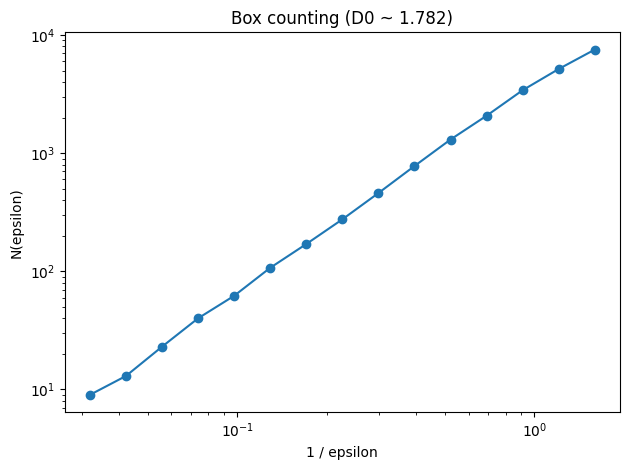

Box-counting dimension D0 ~ 1.782
Correlation dimension D2 ~ 2.149
Expected: D0 >= D2 for the same attractor.


In [10]:
def box_counting_dimension(points, n_eps=15):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    span = np.maximum(maxs - mins, 1e-12)
    pts = (points - mins) / span

    diam = np.linalg.norm(span)
    epsilons = np.logspace(np.log10(diam * 1e-2), np.log10(diam * 0.5), n_eps)

    N_boxes = []
    for eps in epsilons:
        bins = np.maximum((pts / (eps / diam)).astype(int), 0)
        uniq = np.unique(bins, axis=0)
        N_boxes.append(len(uniq))

    N_boxes = np.asarray(N_boxes, dtype=float)
    mask = N_boxes > 0
    log_inv_eps = np.log10(1.0 / epsilons[mask])
    log_N = np.log10(N_boxes[mask])
    lo, hi = np.quantile(log_inv_eps, 0.2), np.quantile(log_inv_eps, 0.8)
    band = (log_inv_eps >= lo) & (log_inv_eps <= hi)
    slope, _ = np.polyfit(log_inv_eps[band], log_N[band], 1)
    return float(slope), epsilons[mask], N_boxes[mask]

X_box = reconstruct_matrix(x_series, tau_opt, m_opt)
d0, eps_plot, N_plot = box_counting_dimension(X_box)

fig, ax = plt.subplots()
ax.loglog(1.0 / eps_plot, N_plot, "o-")
ax.set_xlabel("1 / epsilon")
ax.set_ylabel("N(epsilon)")
ax.set_title(f"Box counting (D0 ~ {d0:.3f})")
plt.tight_layout()
plt.show()

print(f"Box-counting dimension D0 ~ {d0:.3f}")
print(f"Correlation dimension D2 ~ {d2_sat:.3f}")
print("Expected: D0 >= D2 for the same attractor.")